In [8]:
%pip install requirements.txt

import pandas as pd
import numpy as np

### Extraction

In [23]:
df_raw = pd.read_csv('candidates.csv')

In [26]:
# Display initial shape and missing values
print("Initial shape:", df_raw.shape)
print("\nMissing values before cleaning:\n", df_raw.isnull().sum())

print("\nAttribute types in df_raw:")
print(df_raw.dtypes)

Initial shape: (50000, 10)

Missing values before cleaning:
 First Name                 0
Last Name                  0
Email                   2509
Country                    0
Application Date           0
Yoe                     2491
Seniority               2511
Technology                 0
Code Challenge Score       0
Technical Interview     2506
dtype: int64

Attribute types in df_raw:
First Name                  str
Last Name                   str
Email                       str
Country                     str
Application Date            str
Yoe                     float64
Seniority                   str
Technology                  str
Code Challenge Score      int64
Technical Interview     float64
dtype: object


### Transformation
Data cleaning and NA handling

In [ ]:
# 1. Drop rows with missing identifiers (Email or Application Date)
df_clean = df_raw.dropna(subset=['Email', 'Application Date']).copy()

# 2. Convert Application Date to datetime format
df_clean['Application Date'] = pd.to_datetime(df_clean['Application Date'], errors='coerce')
df_clean = df_clean.dropna(subset=['Application Date'])

# 3. Handle Missing Scores: Assume missing means the test was not taken (score = 0)
df_clean['Code Challenge Score'] = df_clean['Code Challenge Score'].fillna(0)
df_clean['Technical Interview'] = df_clean['Technical Interview'].fillna(0)

# 4. Handle Missing YOE based on Seniority grouping (Statistical Imputation)
df_clean = df_clean.rename(columns={'Yoe': 'YOE'})
yoe_by_seniority = df_clean.groupby('Seniority')['YOE'].transform('median')
df_clean['YOE'] = df_clean['YOE'].fillna(yoe_by_seniority)
df_clean['YOE'] = df_clean['YOE'].fillna(df_clean['YOE'].median())

# 5. Handle Missing Categorical Data (Country & Technology) using Mode
mode_country = df_clean['Country'].mode()[0]
mode_technology = df_clean['Technology'].mode()[0]
mode_seniority = df_clean['Seniority'].mode()[0]

df_clean['Country'] = df_clean['Country'].fillna(mode_country)
df_clean['Technology'] = df_clean['Technology'].fillna(mode_technology)
df_clean['Seniority'] = df_clean['Seniority'].fillna(mode_seniority)

# 6. Outlier Treatment for YOE using IQR (Winsorization)
def cap_outliers_iqr(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return np.clip(group, lower_bound, upper_bound)

# Apply the function grouped by Seniority to keep business context
df_clean['YOE'] = df_clean.groupby('Seniority')['YOE'].transform(cap_outliers_iqr)

# Round the years of experience to maintain integer format for the Data Warehouse
df_clean['YOE'] = np.round(df_clean['YOE']).astype(int)


In [46]:
print("Missing values after cleaning:\n", df_clean.isnull().sum())

print(df_clean.shape)

print("\nAttribute types in df_clean:")
print(df_clean.dtypes)

Missing values after cleaning:
 First Name              0
Last Name               0
Email                   0
Country                 0
Application Date        0
YOE                     0
Seniority               0
Technology              0
Code Challenge Score    0
Technical Interview     0
is_hired                0
dtype: int64
(47491, 11)

Attribute types in df_clean:
First Name                         str
Last Name                          str
Email                              str
Country                            str
Application Date        datetime64[us]
YOE                              int64
Seniority                          str
Technology                         str
Code Challenge Score             int64
Technical Interview            float64
is_hired                          bool
dtype: object


Create the Bussiness Rule and data ready to be load adapted for DDM star-schema

In [37]:
# Apply the "HIRED" rule: Both scores must be >= 7[cite: 1]
df_clean['is_hired'] = ((df_clean['Code Challenge Score'] >= 7) &(df_clean['Technical Interview'] >= 7))


# 1. dim_technology
dim_technology = pd.DataFrame(df_clean['Technology'].unique(), columns=['technology_name']).reset_index()
dim_technology.rename(columns={'index': 'technology_id'}, inplace=True)

# 2. dim_country
dim_country = pd.DataFrame(df_clean['Country'].unique(), columns=['country_name']).reset_index()
dim_country.rename(columns={'index': 'country_id'}, inplace=True)

# 3. dim_seniority
dim_seniority = pd.DataFrame(df_clean['Seniority'].unique(), columns=['seniority_name']).reset_index()
dim_seniority.rename(columns={'index': 'seniority_id'}, inplace=True)

# 4. dim_date
dim_date = pd.DataFrame(df_clean['Application Date'].unique(), columns=['date_id'])
dim_date['year'] = dim_date['date_id'].dt.year
dim_date['month'] = dim_date['date_id'].dt.month
dim_date['day'] = dim_date['date_id'].dt.day

# 5. dim_candidate
dim_candidate = df_clean[['First Name', 'Last Name', 'Email']].drop_duplicates().reset_index(drop=True)
dim_candidate = dim_candidate.reset_index().rename(columns={
    'index': 'candidate_id', 
    'First Name': 'first_name', 
    'Last Name': 'last_name', 
    'Email': 'email'
})


# Merge to map IDs into the fact table
df_fact = df_clean.copy()
df_fact = df_fact.merge(dim_technology, left_on='Technology', right_on='technology_name')
df_fact = df_fact.merge(dim_country, left_on='Country', right_on='country_name')
df_fact = df_fact.merge(dim_seniority, left_on='Seniority', right_on='seniority_name')
df_fact = df_fact.merge(dim_candidate, left_on='Email', right_on='email')

# Select only numerical, boolean, and foreign key columns for the fact table
fact_applications = df_fact[[
    'candidate_id',
    'country_id',
    'seniority_id',
    'technology_id',
    'Application Date',
    'YOE',
    'Code Challenge Score',
    'Technical Interview',
    'is_hired'
]].copy()

fact_applications.rename(columns={
    'Technical Interview': 'Technical Interview Score'
}, inplace=True)

# Rename to match database schema conventions
fact_applications.rename(columns={
    'Application Date': 'date_id',
    'YOE': 'yoe',
    'Code Challenge Score': 'code_challenge_score',
    'Technical Interview Score': 'technical_interview_score'
}, inplace=True)

# Generate incremental ID for the fact table
fact_applications = fact_applications.reset_index().rename(columns={'index': 'application_id'})

In [38]:
fact_applications.head(5)

,application_id,candidate_id,country_id,seniority_id,technology_id,date_id,yoe,code_challenge_score,technical_interview_score,is_hired
0,0,0,0,0,0,2024-11-23,6,0,0.0,False
1,1,1,1,1,0,2025-03-21,19,9,6.0,False
2,2,2,2,1,0,2024-10-12,14,2,5.0,False
3,3,27942,2,1,0,2024-10-12,14,2,5.0,False
4,4,3,3,2,1,2024-10-29,10,3,0.0,False


### LOAD

At this point you must have a database ready and running.
For this workshop use postgreSQL 18.6 and pgadmin4 to make easy creation of database, but every query or process can be doit by this nb.

In [39]:
from sqlalchemy import create_engine
import psycopg2

# 1. set credentials for the PostgreSQL database
USER = 'postgres'
PASSWORD = 'Ab123456*'
HOST = 'localhost'
PORT = '5432'
DB_NAME = 'candidates'

# 2. create the database connection string
db_url = f'postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}'
engine = create_engine(db_url)

# 3. Load dimension tables into the database
dim_date.to_sql('dim_date', engine, if_exists='replace', index=False)
dim_country.to_sql('dim_country', engine, if_exists='replace', index=False)
dim_technology.to_sql('dim_technology', engine, if_exists='replace', index=False)
dim_seniority.to_sql('dim_seniority', engine, if_exists='replace', index=False)
dim_candidate.to_sql('dim_candidate', engine, if_exists='replace', index=False)


# 4. Load fact table into the database
fact_applications.to_sql('fact_applications', engine, if_exists='replace', index=False)

567

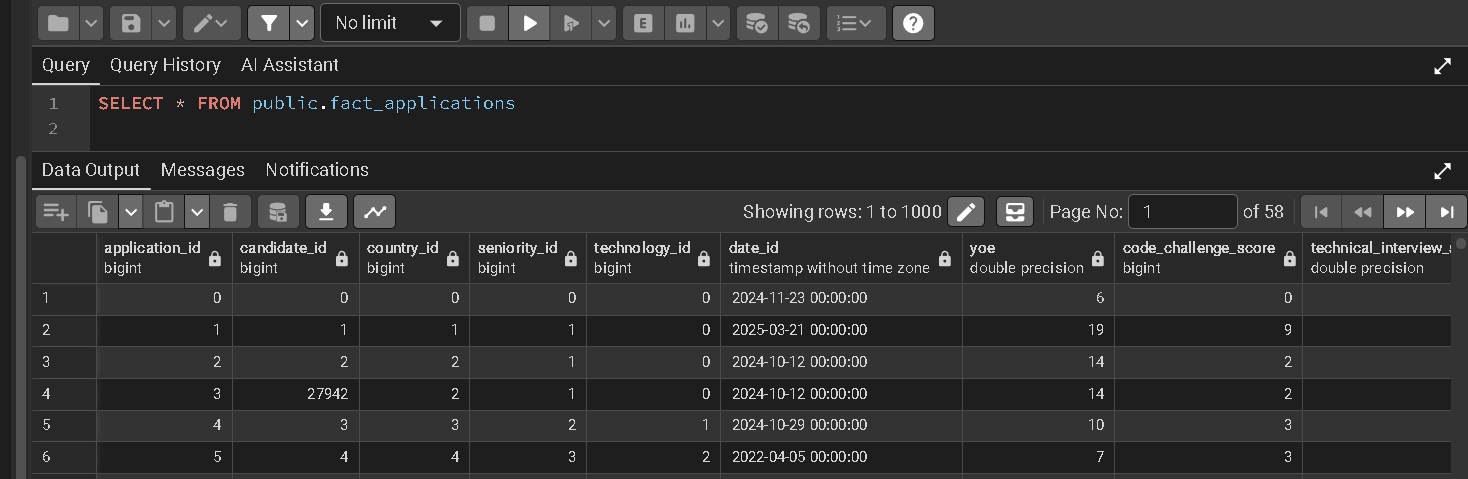

### KPIs and Visualization from DW

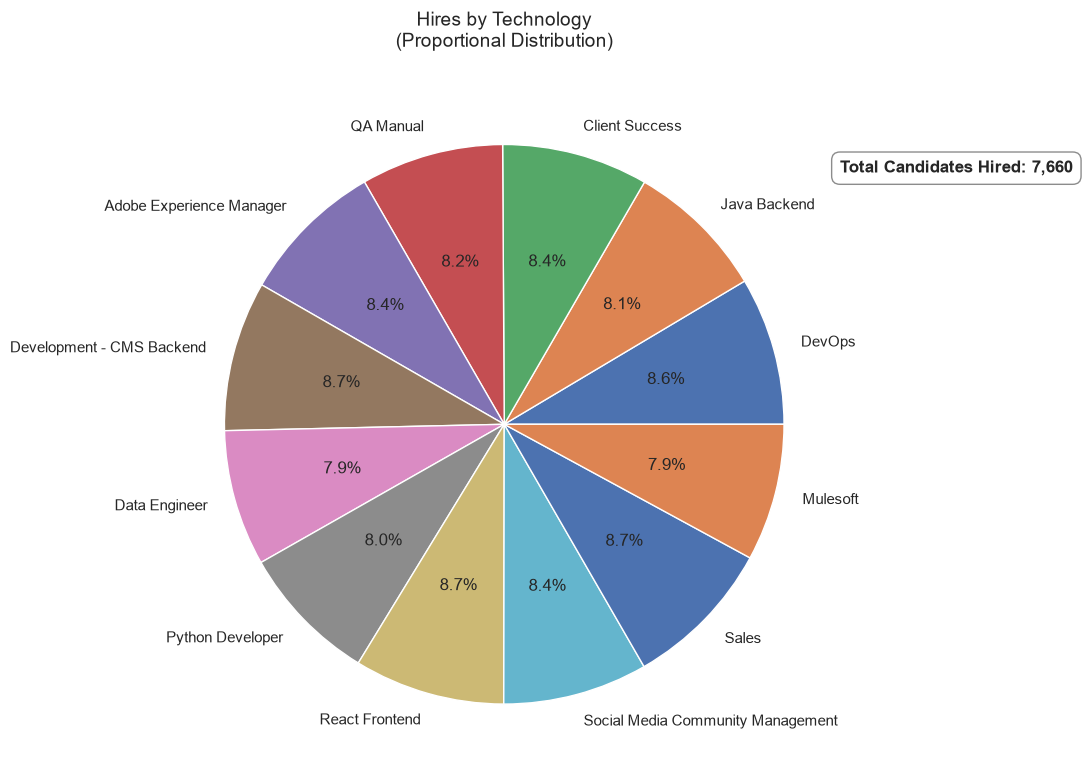

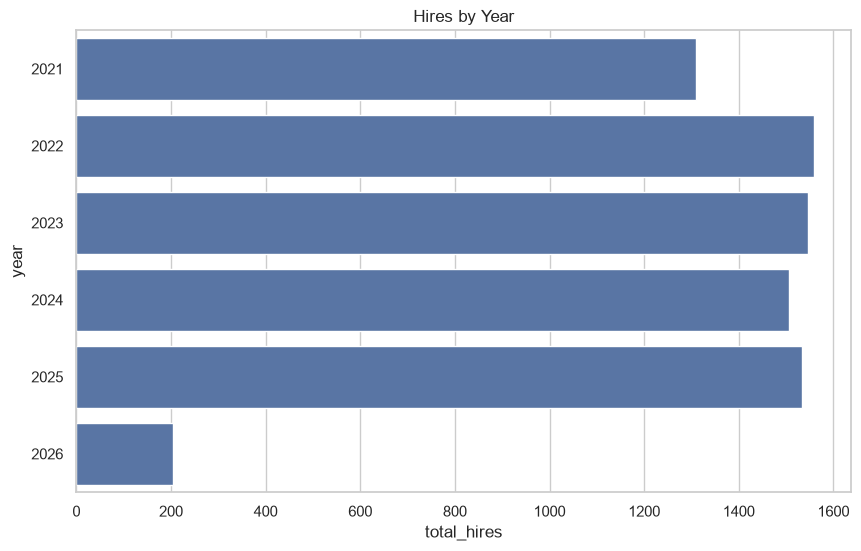

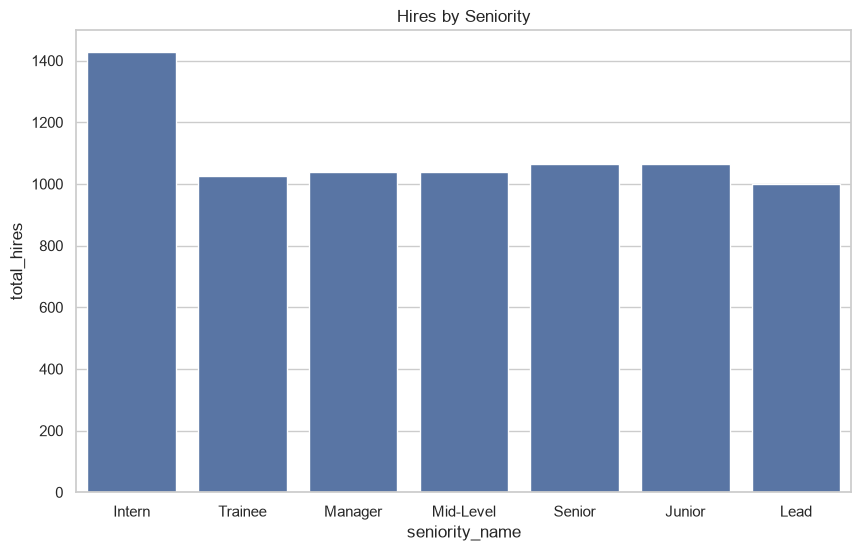

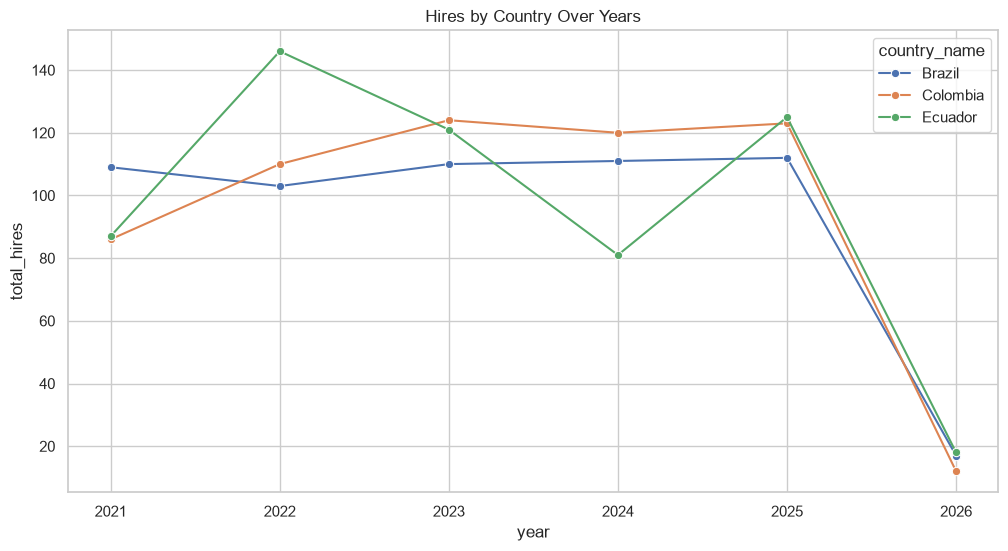

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de gráficos
sns.set_theme(style="whitegrid")

# a. Hires by technology (Pie chart)
query_tech = """
SELECT t.technology_name, COUNT(f.application_id) as total_hires
FROM fact_applications f
JOIN dim_technology t ON f.technology_id = t.technology_id
WHERE f.is_hired = true 
GROUP BY t.technology_name;
"""
df_tech = pd.read_sql(query_tech, engine)

total_hired = df_tech['total_hires'].sum()

# set pie chart
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    df_tech['total_hires'], 
    labels=df_tech['technology_name'], 
    autopct='%1.1f%%'
)

# Añadir el título
plt.title('Hires by Technology\n(Proportional Distribution)', fontsize=14, pad=20)

# Añadir el cuadro de texto con el total
bbox_props = dict(boxstyle="round,pad=0.5", fc="white", ec="gray", lw=1, alpha=0.9)
ax.text(
    1.2, 0.9, # Posición (x, y) fuera del pastel principal
    f"Total Candidates Hired: {total_hired:,}", 
    fontsize=12,
    fontweight='bold',
    bbox=bbox_props
)

plt.tight_layout()
plt.show()

# b. Hires by year (Horizontal bar chart)
query_year = """
SELECT d.year, COUNT(f.application_id) as total_hires
FROM fact_applications f
JOIN dim_date d ON f.date_id = d.date_id
WHERE f.is_hired = true GROUP BY d.year ORDER BY d.year;
"""
df_year = pd.read_sql(query_year, engine)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_year, x='total_hires', y='year', orient='h')
plt.title('Hires by Year')
plt.show()

# c. Hires by seniority (Bar chart)
query_seniority = """
SELECT s.seniority_name, COUNT(f.application_id) as total_hires
FROM fact_applications f
JOIN dim_seniority s ON f.seniority_id = s.seniority_id
WHERE f.is_hired = true GROUP BY s.seniority_name;
"""
df_seniority = pd.read_sql(query_seniority, engine)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_seniority, x='seniority_name', y='total_hires')
plt.title('Hires by Seniority')
plt.show()

# d. Hires by country over years (Multiline chart)
query_country = """
SELECT c.country_name, d.year, COUNT(f.application_id) as total_hires
FROM fact_applications f
JOIN dim_country c ON f.country_id = c.country_id
JOIN dim_date d ON f.date_id = d.date_id
WHERE f.is_hired = true AND c.country_name IN ('United States of America', 'Brazil', 'Colombia', 'Ecuador')
GROUP BY c.country_name, d.year ORDER BY d.year, c.country_name;
"""
df_country = pd.read_sql(query_country, engine)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_country, x='year', y='total_hires', hue='country_name', marker='o')
plt.title('Hires by Country Over Years')
plt.xticks(df_country['year'].unique().astype(int))
plt.show()